<table style="width: 100%; border-collapse: collapse; border: none;">
<tr>
<td style="border: 2px solid #1a2a6c; border-radius: 15px; background-color: #f8f9fa; padding: 40px; text-align: center;">
<h1 style="color: #1a2a6c; margin-bottom: 0px; font-size: 36px; font-family: sans-serif;">
<b>🚀 Retail Demand Forecasting</b>
</h1>
<p style="color: #666; font-style: italic; font-size: 18px; margin-top: 10px; font-family: sans-serif;">
Forecasting 2,000 retail sales time series with global machine learning models in Python (Darts)
</p>
<hr style="width: 50%; border: 0; border-top: 1px solid #ddd; margin: 20px auto;">
<div style="font-family: sans-serif; font-size: 16px;">
<span style="color: #333;">Author:</span>
<a href="https://github.com/LunaPerezT" style="color: #3498db; text-decoration: none; font-weight: bold;">Luna Pérez T.</a>
</div>
<br></br>
<div style="background-color: #1a2a6c; color: white; display: inline-block; padding: 10px 10px; border-radius: 5px; font-weight: bold; font-family: sans-serif;">
PART 1 : Problem Statement and Exploratory Data Analysis
</div>
</td>
</tr>
</table>


## **1. Problem Statement**

This project builds a daily sales forecasting model for a retail chain: **predicting the daily sales of every product in every store for January 2016**, from three years of history.

The dataset covers the sales history of **500 distinct products**, each characterised by:

- **`product_id`**: unique product identifier.
- **`cat_id`**: the category the product belongs to (A, B or C).
- **`subcat_id`**: sub-category or product family within each category.
- **`store_id`**: point of sale (4 stores in total).

Since all 500 products are sold in all 4 stores, the prediction space covers **2,000 product-store combinations**, and for each of them **31 daily predictions** must be generated (one per day of January 2016), giving a total of **62,000 rows** in the output file.

Alongside the sales history (`sales.csv`), we have the **price of each product per store and date** (`prices.csv`), which lets us bring price in as an exogenous variable and capture possible price-demand elasticity effects.

The output file has the columns: `id_`, `product_id`, `subcat_id`, `cat_id`, `store_id`, `snapshot_date` and `sales`.

---

## **2.  Setup, Data Loading & Conversion to the Darts Format**



First we import the libraries used throughout this notebook.

In [1]:
import warnings , os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
# Allows the notebook to run either from notebooks/ or from the repository root.
import os
from pathlib import Path

if not Path('data').is_dir() and Path('..', 'data').is_dir():
    os.chdir('..')
print('Working directory:', Path.cwd())

Working directory: /tmp/exec


We load the sales data.

In [3]:
df_raw = pd.read_csv('data/sales.csv', sep=';')
df_raw.head(3)


,id_,cat_id,store_id,subcat_id,product_id,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,...,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-26,2015-12-27,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,A_1_008_1,A,1,1,A_1_008,1.0,1.0,0.0,1.0,0.0,...,20.0,6.0,9.0,0.0,17.0,0.0,8.0,2.0,10.0,7.0
1,A_1_010_1,A,1,1,A_1_010,3.0,3.0,3.0,1.0,1.0,...,1.0,1.0,2.0,0.0,0.0,3.0,0.0,3.0,1.0,0.0
2,A_1_013_1,A,1,1,A_1_013,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 1100 entries, id_ to 2015-12-31
dtypes: float64(1095), int64(2), str(3)
memory usage: 16.8 MB


In [5]:
META_COLS = ['id_', 'cat_id', 'store_id', 'subcat_id', 'product_id']
DATE_COLS = [c for c in df_raw.columns if c not in META_COLS]


print(f'Rows (series)   : {len(df_raw):,}')
print(f'Dates           : {DATE_COLS[0]} → {DATE_COLS[-1]}  ({len(DATE_COLS)} days)')
print(f'Unique products : {df_raw.product_id.nunique()}')
print(f'Stores          : {df_raw.store_id.nunique()}')
print(f'Categories      : {sorted(df_raw.cat_id.unique())}')
print(f'Sub-categories  : {sorted(df_raw.subcat_id.unique().tolist())}')


Rows (series)   : 2,000
Dates           : 2013-01-01 → 2015-12-31  (1095 days)
Unique products : 500
Stores          : 4
Categories      : ['A', 'B', 'C']
Sub-categories  : [1, 2, 3]


As we can see there are 2,000 time series in total, running from 1 January 2013 to 31 December 2015 (three years long). They correspond to the sales of each of the 500 products across the four stores that make up this chain.

Since the time series run horizontally across the columns, we will reshape the data into the layout that is standard for time series — vertical — using `melt`.

In [6]:
df_long = df_raw.melt(id_vars=META_COLS, value_vars=DATE_COLS, var_name='ds', value_name='y')
df_long=df_long.assign(ds=pd.to_datetime(df_long['ds']),y=df_long['y'].astype('float32'))
df_long=df_long.sort_values(['id_', 'ds']).rename(columns={'id_': 'unique_id'}).reset_index(drop=True)
print(f'Reshaped dataframe dimensions: {df_long.shape}')
df_long.head(4)

Reshaped dataframe dimensions: (2190000, 7)


,unique_id,cat_id,store_id,subcat_id,product_id,ds,y
0,A_1_008_1,A,1,1,A_1_008,2013-01-01,1.0
1,A_1_008_1,A,1,1,A_1_008,2013-01-02,1.0
2,A_1_008_1,A,1,1,A_1_008,2013-01-03,0.0
3,A_1_008_1,A,1,1,A_1_008,2013-01-04,1.0


In [7]:
df_prices = pd.read_csv('data/prices.csv',sep=";")
df_prices.head(4)

,snapshot_date,product_id,store_id,price
0,2013-01-01,A_1_008,1,1.30
1,2013-01-01,A_1_010,1,3.76
2,2013-01-01,A_1_013,1,3.20
3,2013-01-01,A_1_022,1,8.08


In [8]:
df_prices.info()

<class 'pandas.DataFrame'>
RangeIndex: 2252000 entries, 0 to 2251999
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   snapshot_date  str    
 1   product_id     str    
 2   store_id       int64  
 3   price          float64
dtypes: float64(1), int64(1), str(2)
memory usage: 105.2 MB


In [9]:
df_prices['snapshot_date'] = pd.to_datetime(df_prices['snapshot_date'])
df_prices['price'] = df_prices['price'].astype('float32')
df_prices['unique_id'] = (df_prices['product_id'].astype(str) + '_' +df_prices['store_id'].astype(str))
df_long = df_long.merge(df_prices[['unique_id', 'snapshot_date', 'price']].rename(columns={'snapshot_date': 'ds'}),on=['unique_id', 'ds'], how='left')
df_long.head(4)


,unique_id,cat_id,store_id,subcat_id,product_id,ds,y,price
0,A_1_008_1,A,1,1,A_1_008,2013-01-01,1.0,1.30
1,A_1_008_1,A,1,1,A_1_008,2013-01-02,1.0,1.42
2,A_1_008_1,A,1,1,A_1_008,2013-01-03,0.0,1.69
3,A_1_008_1,A,1,1,A_1_008,2013-01-04,1.0,1.08


In [10]:
df_long.isnull().sum()

unique_id     0
cat_id        0
store_id      0
subcat_id     0
product_id    0
ds            0
y             0
price         0
dtype: int64

## **3. Exploratory Data Analysis (EDA)**

Before building any model it is essential to understand the nature and structure of the data. This section carries out an exploratory analysis with the following goals:

- **General inspection of the dataset**: the historical range of the data at different scales, and first descriptive statistics.
- **Sales distribution**: analysis of the sales distribution globally and by category, sub-category and store, to detect skew, outliers or extreme behaviour.
- **Temporal evolution**: visualisation of the aggregated series to identify global trends, weekly seasonality and calendar effects (holidays, end of month, etc.).
- **Segment analysis**: comparison of sales behaviour across categories (`cat_id`), sub-categories (`subcat_id`) and stores (`store_id`).
- **Price-demand relationship**: exploration of the correlation between price variation and sales volume, both globally and per product.


In [11]:
y_vals = df_long['y'].values

print('═'*55)
print('  GLOBAL DAILY SALES STATISTICS')
print('═'*55)
print(f'  Total observations    : {len(y_vals)}')
print(f'  Time series           : {df_long.unique_id.nunique()}')
print(f'  Mean                  : {y_vals.mean()}')
print(f'  Median                : {np.median(y_vals)}')
print(f'  Std                   : {y_vals.std()}')
print(f'  P25 / P75 / P99       : {np.percentile(y_vals,25)} / {np.percentile(y_vals,75)} / {np.percentile(y_vals,99)}')
print(f'  Maximum               : {y_vals.max()}')
print(f'  % Zeros               : {(y_vals==0).mean()*100}%')
print(f'  Skewness              : {stats.skew(y_vals)}')
print(f'  Kurtosis              : {stats.kurtosis(y_vals)}')
print('═'*55)


═══════════════════════════════════════════════════════
  GLOBAL DAILY SALES STATISTICS
═══════════════════════════════════════════════════════
  Total observations    : 2190000
  Time series           : 2000
  Mean                  : 2.8050200939178467
  Median                : 1.0
  Std                   : 5.535671234130859
  P25 / P75 / P99       : 0.0 / 3.0 / 26.0
  Maximum               : 356.0
  % Zeros               : 29.44219178082192%
  Skewness              : 7.589689254760742
  Kurtosis              : 122.44188690185547
═══════════════════════════════════════════════════════


In this section we derive a set of features on the main dataset that will help us visualise the data in this notebook and later train the model. We also set up plotting defaults and a folder where every figure in this section will be saved. We start by plotting the sales values of the dataset, excluding zeros.


In [12]:
df_long['dow']   = df_long['ds'].dt.dayofweek
df_long['month'] = df_long['ds'].dt.month
df_long['year']  = df_long['ds'].dt.year
df_long['doy']   = df_long['ds'].dt.dayofyear

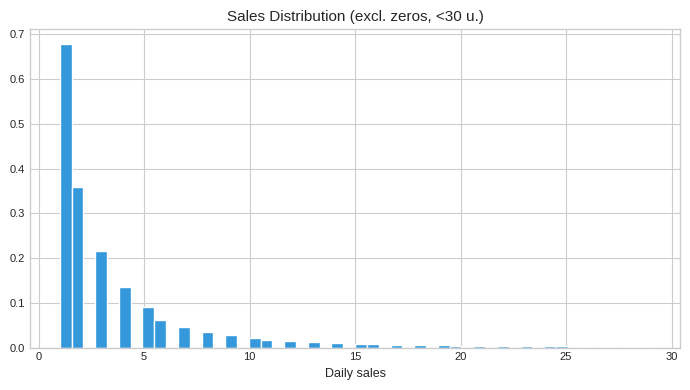

In [13]:
os.makedirs('outputs', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'axes.titlesize':11,'axes.labelsize':9,'xtick.labelsize':8,'ytick.labelsize':8})

fig, ax = plt.subplots(figsize=(7, 4))
y_nz = y_vals[(y_vals > 0) & (y_vals < 30)]
ax.hist(y_nz, bins=50, color='#3498DB', edgecolor='white', density=True)
ax.set_title('Sales Distribution (excl. zeros, <30 u.)')
ax.set_xlabel('Daily sales')
plt.tight_layout()
plt.savefig('outputs/eda_01_sales_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

As we can see, the sales distribution is strongly right-skewed, with most of its mass concentrated at 1.

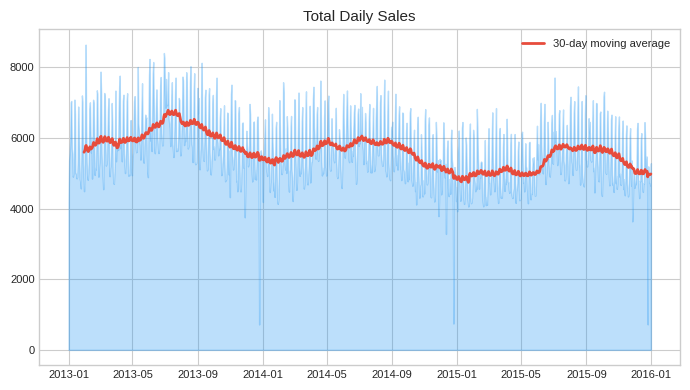

In [14]:
daily = df_long.groupby('ds')['y'].sum()
fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(daily.index, daily.values, alpha=0.3, color='#2196F3')
ax.plot(daily.index, daily.rolling(30).mean(), color='#E74C3C', lw=2, label='30-day moving average')
ax.set_title('Total Daily Sales')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_02_daily_sales.png', dpi=130, bbox_inches='tight')
plt.show()

There is an annual periodicity in the total sales summed across all stores, and every year we see a minimum around one day of the Christmas period.

In [15]:
df_long.groupby('ds')['y'].sum().sort_values()[:3]

ds
2013-12-25    719.0
2015-12-25    721.0
2014-12-25    745.0
Name: y, dtype: float32

Specifically, on Christmas Day there is always a drop in the sales of every product. It will therefore be very useful to include covariates carrying annual periodicity, and we could consider flagging this particular date in some way so that the model learns this drop.

Next we show a boxplot of the sales distribution by product category.

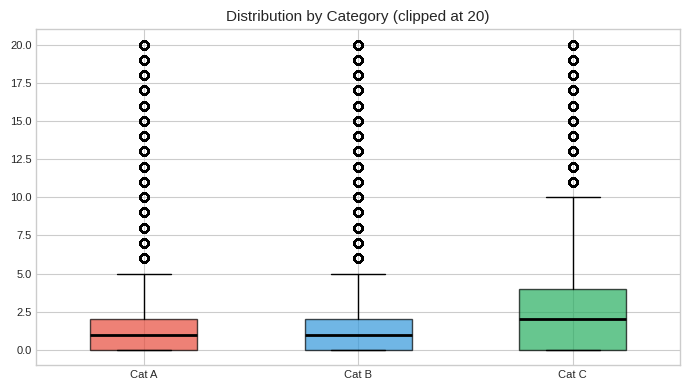

In [16]:
COLORS=dict(A='#E74C3C', B='#3498DB', C='#27AE60')

fig, ax = plt.subplots(figsize=(7, 4))
for i, (cat, grp) in enumerate(df_long.groupby('cat_id')['y']):
    ax.boxplot(grp.clip(0, 20), positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=COLORS[str(cat)], alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Cat A', 'Cat B', 'Cat C'])
ax.set_title('Distribution by Category (clipped at 20)')
plt.tight_layout()
plt.savefig('outputs/eda_03_category_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()

The median sits at around one sale per day except for category C. It is worth noting that there are a great many outliers in daily sales: products in every category sometimes reach 20 sales a day.

Next we plot the distribution of the percentage of zeros across the time series that make up the sales of each product in each store, using a histogram.

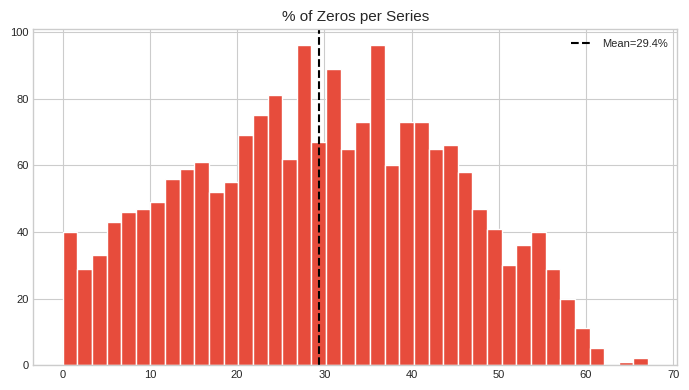

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
zero_by_series = df_long.groupby('unique_id')['y'].apply(lambda x: (x == 0).mean() * 100)
ax.hist(zero_by_series, bins=40, color='#E74C3C', edgecolor='white')
ax.axvline(zero_by_series.mean(), color='black', ls='--',
           label=f'Mean={zero_by_series.mean():.1f}%')
ax.set_title('% of Zeros per Series')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_04_zeros_per_series.png', dpi=130, bbox_inches='tight')
plt.show()

The share of zeros across the different product series averages 29.4%, reaching 65% in some cases. This will make prediction harder. With that in mind we can use both evaluation metrics and loss functions adapted to this regime of instability and heavy presence of zeros.

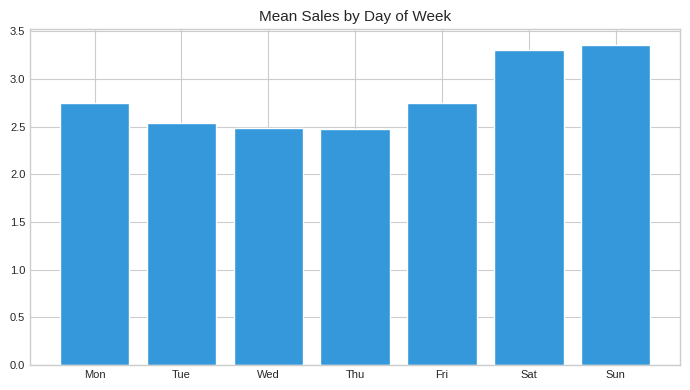

In [18]:
DAYS  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(7, 4))
dow_mean = df_long.groupby('dow')['y'].mean()
ax.bar(range(7), dow_mean.values, color='#3498DB', edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Mean Sales by Day of Week')
plt.tight_layout()
plt.savefig('outputs/eda_05_mean_by_weekday.png', dpi=130, bbox_inches='tight')
plt.show()

Sales follow a marked weekly cycle. It peaks on Sunday, followed by Saturday and Monday, and bottoms out on Thursday, followed by Wednesday.

Next we plot mean sales, this time by month.

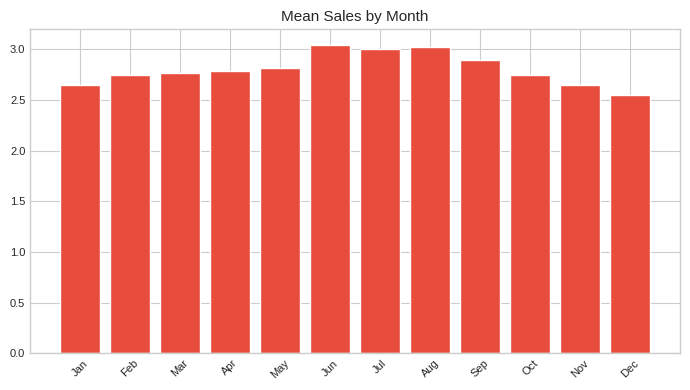

In [19]:
MONTHS= ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(7, 4))
month_mean = df_long.groupby('month')['y'].mean()
ax.bar(range(12), month_mean.values, color='#E74C3C', edgecolor='white')
ax.set_xticks(range(12))
ax.set_xticklabels(MONTHS, rotation=45)
ax.set_title('Mean Sales by Month')
plt.tight_layout()
plt.savefig('outputs/eda_06_mean_by_month.png', dpi=130, bbox_inches='tight')
plt.show()

As already noted there is an annual cycle in sales, peaking in summer (June-July) and bottoming out in December.

Next we plot mean sales across months and days of the week, using a heatmap.

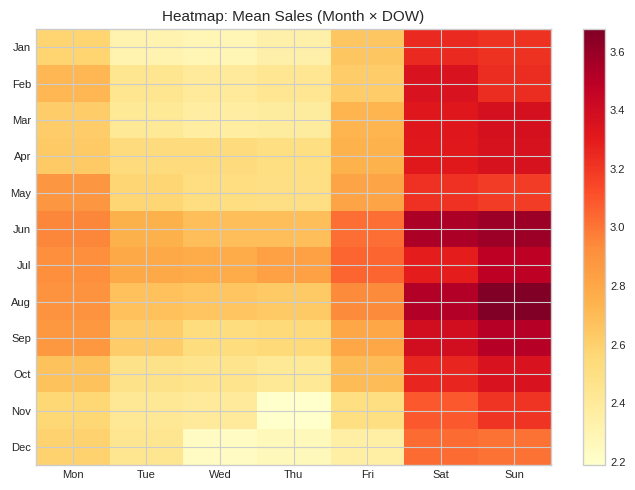

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
heat = df_long.groupby(['month','dow'])['y'].mean().unstack()
im = ax.imshow(heat.values, cmap='YlOrRd', aspect='auto')
ax.set_yticks(range(12))
ax.set_yticklabels(MONTHS)
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Heatmap: Mean Sales (Month × DOW)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('outputs/eda_07_heatmap_month_dow.png', dpi=130, bbox_inches='tight')
plt.show()

This chart shows a rise in mean daily sales especially at weekends, and especially in summer, the highest being the Sundays of August.

In [21]:
print('\n=== Mean sales by CATEGORY × STORE ===')
print(df_long.pivot_table('y', index='cat_id', columns='store_id', aggfunc='mean').round(3))



=== Mean sales by CATEGORY × STORE ===


store_id      1      2      3      4
cat_id                              
A         2.588  1.620  2.587  1.901
B         1.592  1.750  3.069  0.961
C         4.076  2.814  5.476  2.303


Mean sales are far higher for category C products, especially in store 3, which is the store with the most sales.

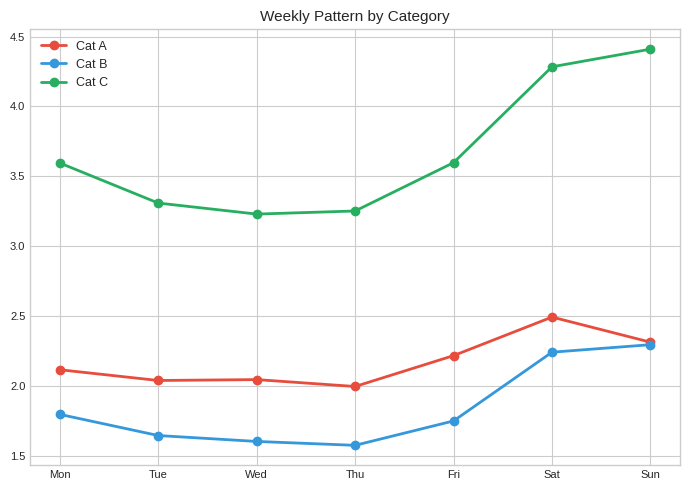

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
for cat, grp in df_long.groupby('cat_id'):
    dm = grp.groupby('dow')['y'].mean()
    ax.plot(range(7), dm.values, marker='o', label=f'Cat {cat}',color=COLORS[str(cat)], lw=2)
ax.set_xticks(range(7))
ax.set_xticklabels(DAYS)
ax.set_title('Weekly Pattern by Category')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/eda_08_weekly_pattern_by_category.png', dpi=130, bbox_inches='tight')
plt.show()

Plotting mean sales by category across the days of the week shows similar trends, although category C rises somewhat on Sundays and is generally higher throughout the week.

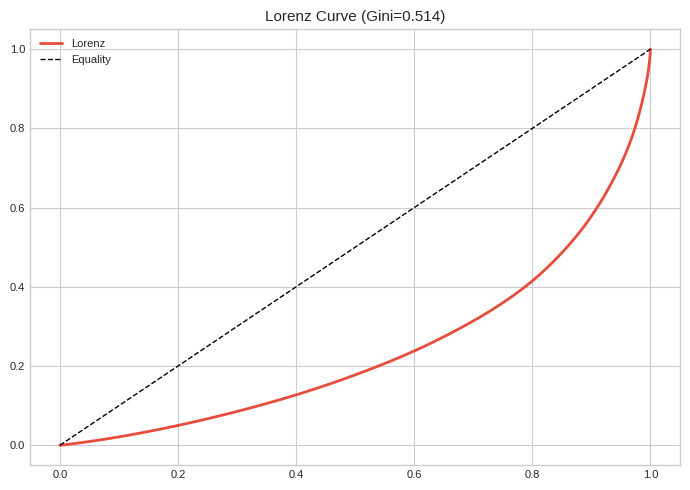

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
st = df_long.groupby('unique_id')['y'].sum().sort_values()
lx = np.linspace(0, 1, len(st))
ly = np.cumsum(st.values) / st.sum()
# Trapezoidal rule written out: np.trapz was removed in NumPy 2.0 and
# np.trapezoid does not exist in 1.x, so neither name is portable.
auc  = np.sum((ly[1:] + ly[:-1]) / 2 * np.diff(lx))
gini = 1 - 2 * auc
ax.plot(lx, ly, color='#E74C3C', lw=2, label='Lorenz')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Equality')
ax.set_title(f'Lorenz Curve (Gini={gini:.3f})')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/eda_09_lorenz_curve.png', dpi=130, bbox_inches='tight')
plt.show()

Both the Lorenz curve and the Gini coefficient show a moderate concentration of sales. The Gini ranges between 0 (total equality, every product sells the same) and 1 (total inequality, a single product accounts for all sales). Ours sits at 0.514, roughly halfway: some series sell more and others less, but they are moderately concentrated.

Next we study the autocorrelation (*ACF*) and partial autocorrelation (*PACF*) functions.

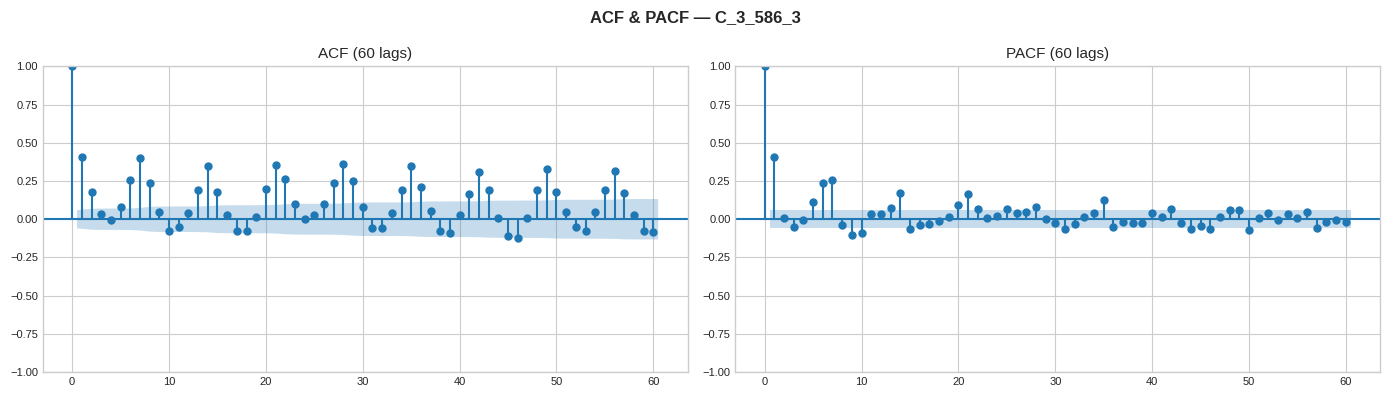

In [24]:
top_uid = df_long.groupby('unique_id')['y'].sum().idxmax()
s_top   = df_long[df_long['unique_id']==top_uid].sort_values('ds')['y'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'ACF & PACF — {top_uid}', fontweight='bold')
plot_acf( s_top, lags=60, ax=axes[0], title='ACF (60 lags)')
plot_pacf(s_top, lags=60, ax=axes[1], title='PACF (60 lags)', method='ywm')
plt.tight_layout()
plt.savefig('outputs/eda_10_acf_pacf_60.png', dpi=130, bbox_inches='tight')
plt.show()


Over a 60-day window we can see a mainly weekly cyclical pattern in both the ACF and the PACF. In particular the ACF stays significantly high at lags 1, 2, 7, 14, 21, 28, 35, 42, 49 and 56. It will therefore be worth trying these lags when training the model.

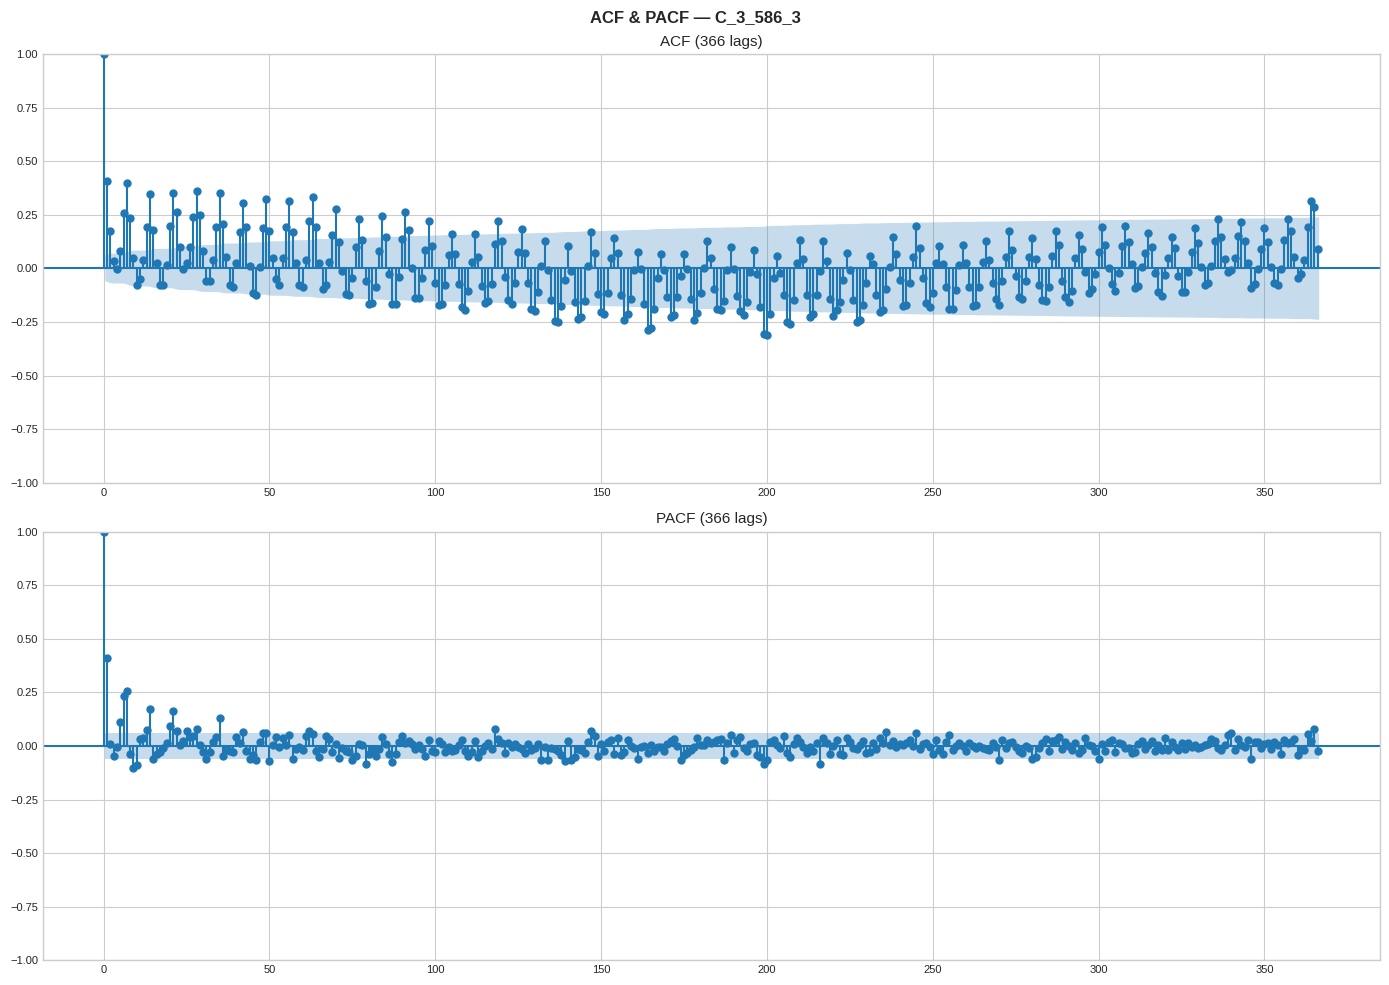

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f'ACF & PACF — {top_uid}', fontweight='bold')
plot_acf( s_top, lags=366, ax=axes[0], title='ACF (366 lags)')
plot_pacf(s_top, lags=366, ax=axes[1], title='PACF (366 lags)', method='ywm')
plt.tight_layout()
plt.savefig('outputs/eda_11_acf_pacf_366.png', dpi=130, bbox_inches='tight')
plt.show()

Extending the window to 366 days shows that both the PACF and the ACF are significantly high at some points reaching out to 120 days. We also see a certain annual cyclical pattern, so we will need to include cyclical covariates encoding month and year, so that the model can learn these patterns.

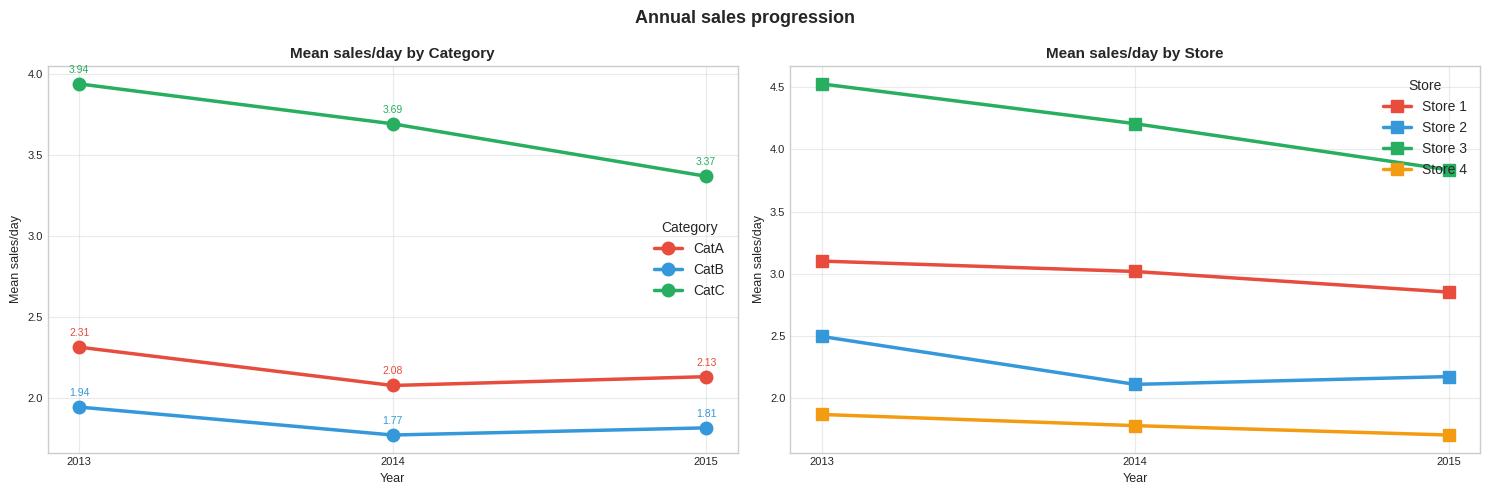

In [26]:
annual_cat = (df_long.assign(year=lambda x: x['ds'].dt.year).groupby(['year','cat_id'])['y'].mean().reset_index())
annual_store = (df_long.assign(year=lambda x: x['ds'].dt.year).groupby(['year','store_id'])['y'].mean().reset_index())
store_palette = ['#E74C3C','#3498DB','#27AE60','#F39C12']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Annual sales progression',fontsize=13, fontweight='bold')

ax = axes[0]
for cat, grp in annual_cat.groupby('cat_id'):
    ax.plot(grp['year'], grp['y'], marker='o', label=f'Cat{cat}',color=COLORS[cat], linewidth=2.5, markersize=9)
    for _, row in grp.iterrows():
        ax.annotate(f'{row["y"]:.2f}', (row['year'], row['y']),textcoords='offset points', xytext=(0, 8),fontsize=7.5, ha='center', color=COLORS[row['cat_id']])
ax.set_title('Mean sales/day by Category', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Mean sales/day')
ax.set_xticks([2013, 2014, 2015])
ax.legend(title='Category'); ax.grid(True, alpha=0.4)

ax = axes[1]
for (sid, grp), col in zip(annual_store.groupby('store_id'), store_palette):
    ax.plot(grp['year'], grp['y'], marker='s', label=f'Store {sid}',color=col, linewidth=2.5, markersize=9)
ax.set_title('Mean sales/day by Store', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Mean sales/day')
ax.set_xticks([2013, 2014, 2015])
ax.legend(title='Store'); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('outputs/eda_12_annual_sales_progression.png', dpi=130, bbox_inches='tight')
plt.show()


It is worth noting that the different categories follow different trends, though some share features. For that reason, using models that predict each product's time series independently — that is, 2,000 local models — would not only be an unwieldy strategy, it would also fail to capture the complexity of the interactions between the series.

To see these patterns at *finer resolution*, we plot mean sales/day by category and store for each month.

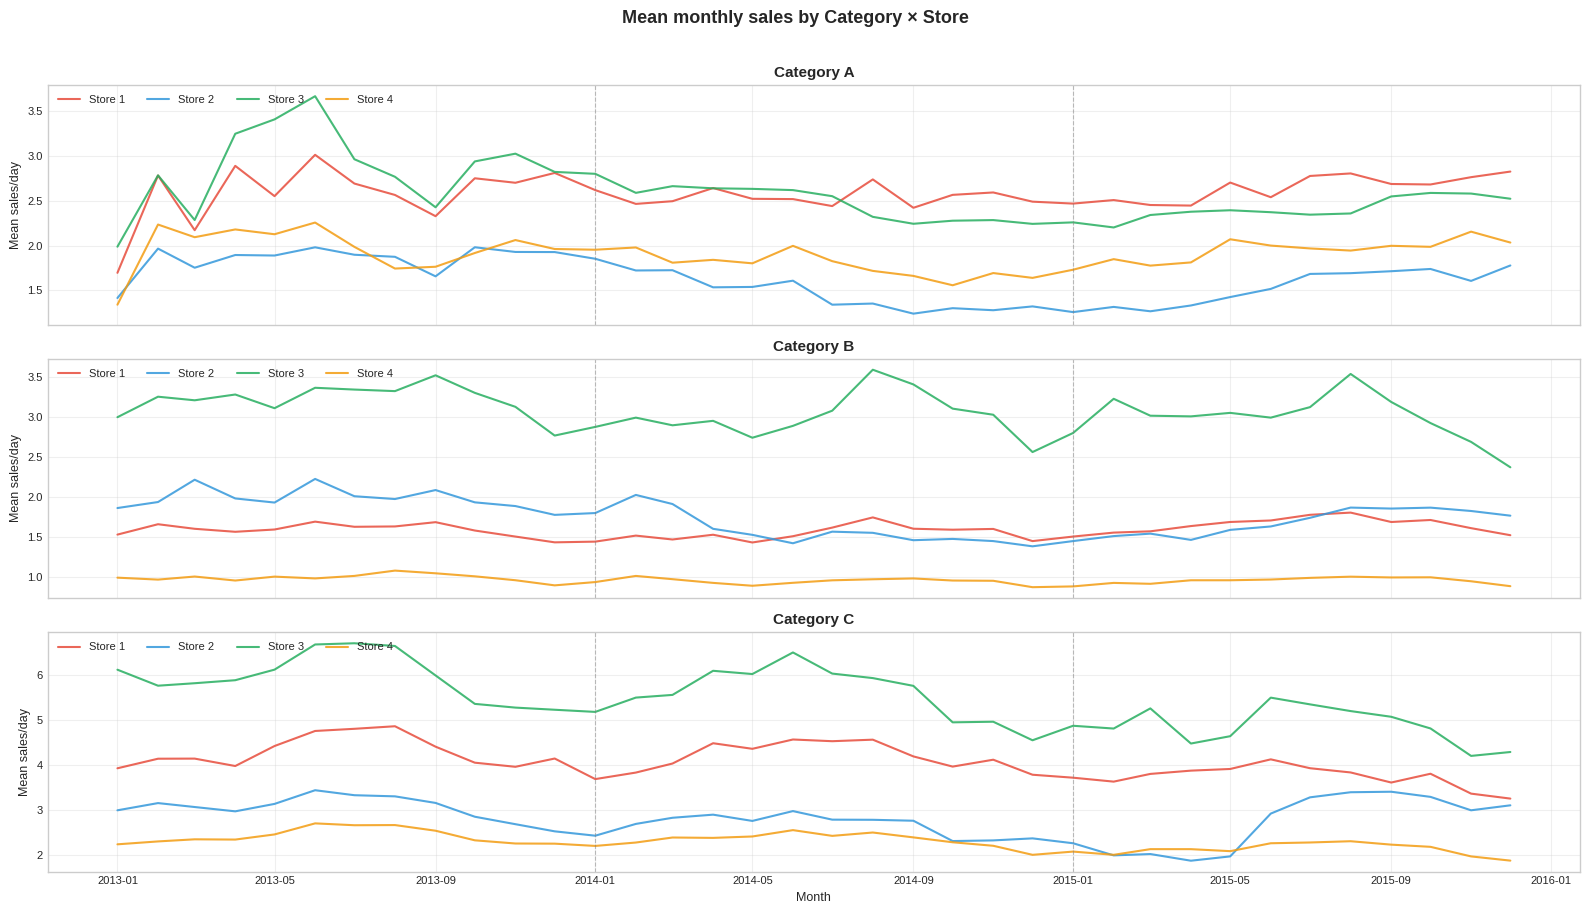

In [27]:
monthly_cat_store = (df_long.assign(ym=lambda x: x['ds'].dt.to_period('M').astype(str))
    .groupby(['ym','cat_id','store_id'])['y'].mean().reset_index()
    .assign(ym_dt=lambda x: pd.to_datetime(x['ym']))
    .sort_values('ym_dt'))
cats = ["A","B","C"]

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Mean monthly sales by Category × Store',fontsize=13, fontweight='bold', y=1.01)

for ax, cat in zip(axes, cats):
    sub = monthly_cat_store[monthly_cat_store['cat_id'] == cat]
    for sid, col in zip(sorted(df_long['store_id'].unique()), store_palette):
        s2 = sub[sub['store_id'] == sid].sort_values('ym_dt')
        ax.plot(s2['ym_dt'], s2['y'], label=f'Store {sid}',color=col, linewidth=1.5, alpha=0.85)
    ax.set_title(f'Category {cat}', fontweight='bold')
    ax.set_ylabel('Mean sales/day')
    ax.legend(ncol=4, fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    for yr in [2014, 2015]:
        ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray',linestyle='--', linewidth=0.8, alpha=0.5)
axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.savefig('outputs/eda_13_monthly_sales_by_category_store.png', dpi=130, bbox_inches='tight')
plt.show()

Here we see far more clearly what was described above: there is both a degree of independence and a degree of dependence between the series. Although each store and each category differs in level and in how it varies, they all share patterns with one another, especially when they belong to the same category or store. This is why it matters that our model captures all of this complexity.

Finally, we plot the relationship between sales and price using a hexbin. This chart shows the density of records observed at each combination of sales and price, revealing the relationship between the two variables.

Pearson r (price vs units, non-zero sales): -0.1955


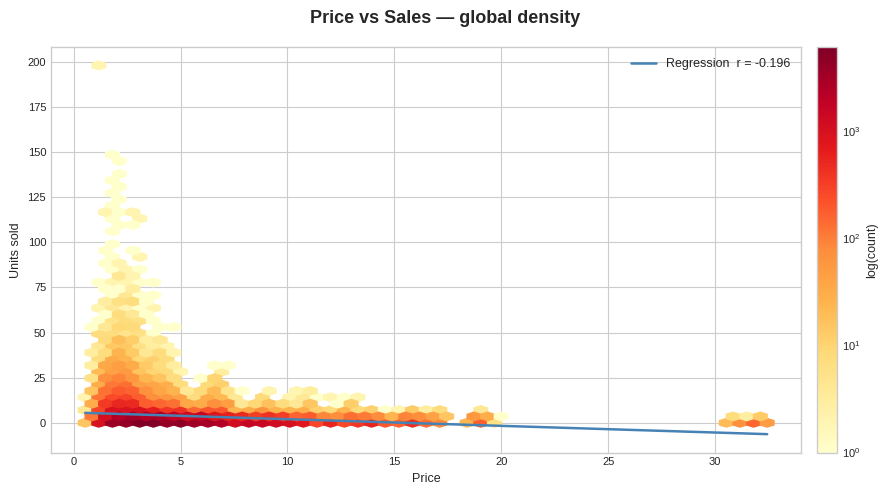

In [28]:
df_p    = df_long.dropna(subset=['price'])
sample1 = df_p.sample(min(80_000, len(df_p)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Price vs Sales — global density', fontweight='bold', fontsize=13)

hb = ax.hexbin(sample1['price'], sample1['y'], gridsize=50, cmap='YlOrRd', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('log(count)', fontsize=9)

m_lr = (sample1['price'] > 0) & (sample1['y'] > 0)
sl, ic, r_gl, *_ = stats.linregress(sample1.loc[m_lr, 'price'], sample1.loc[m_lr, 'y'])
xl = np.linspace(sample1['price'].min(), sample1['price'].max(), 100)
ax.plot(xl, sl * xl + ic, color='steelblue', lw=1.8, label=f'Regression  r = {r_gl:.3f}')
ax.set_xlabel('Price'); ax.set_ylabel('Units sold')
ax.legend(fontsize=9)
print(f'Pearson r (price vs units, non-zero sales): {r_gl:.4f}')

plt.tight_layout()
plt.savefig('outputs/eda_14_price_hexbin.png', dpi=150, bbox_inches='tight')
plt.show()

As we can see the correlation between the variables is slightly negative, meaning sales rise as the product gets cheaper. It will therefore be worth introducing this covariate wherever possible.

---

## **4. Conclusions and Next Steps**

Over the course of this notebook we have carried out a thorough exploratory analysis of the **2,000 time series** that make up the sales dataset (500 products × 4 stores), covering the period 2013-2015. Below are the most relevant findings and the modelling decisions that follow from them.


###  Key EDA findings

| Aspect | Finding | Implication for the model |
|---|---|---|
| **Distribution** | Strong positive skew, mode at 1 unit/day | Avoid metrics sensitive to outliers (e.g. plain MSE) |
| **Zeros** | 29.4% zeros per series on average, up to 65% for some products | Consider models or metrics adapted to intermittent demand |
| **Weekly seasonality** | Peak Sunday-Saturday, trough Wednesday-Thursday | Include `day_of_week` as a covariate; lags 7, 14, 21, 28 |
| **Annual seasonality** | Peak in June-July, trough in December | Include `month` and `day_of_year`; a dedicated Christmas flag |
| **ACF/PACF** | Significant dependencies out to lag 56 (weekly) and ~120 (annual) | Lag windows and moving averages of up to 4 weeks |
| **Category C** | Systematically higher sales, especially in Store 3 | `cat_id` and `store_id` as static covariates |
| **Concentration** | Gini = 0.514 (moderate concentration) | No need for a large-scale separate treatment by volume |
| **Price** | Weak correlation with sales at the global level | Include price as an exogenous covariate, not as a primary predictor |



###  Preprocessing decisions for the next notebook

Based on the findings above, the preprocessing carried out in **Notebook 2** will follow these lines:

1. **Temporal feature engineering**: `day_of_week`, `month`, `day_of_year`, `week_of_year`, a weekend flag and a Christmas Day flag (25 December).
2. **Lag variables**: sales lags at $t-7$, $t-14$, $t-21$ and $t-28$ days to capture the weekly seasonality identified in the ACF.
3. **Moving averages**: mean and standard deviation of sales over 7-, 14- and 28-day windows.
4. **Price variables**: current price, percentage change versus the previous week ($\Delta\%$ WoW) and price relative to the product's historical mean.
5. **Categorical encoding**: `cat_id`, `subcat_id` and `store_id` via label encoding, since the gradient boosting models we will use handle this kind of encoding well.
6. **Temporal train/validation split**: **December 2015** will be held out as the validation set, preserving temporal order and simulating the real scenario of forecasting the following month.

---


To move on to the next notebook we save the dataframe we reshaped to long format and joined to prices as a parquet file, so that all the dtypes and changes we made are preserved.

In [29]:
df_long.to_parquet('./data/preprocessed_data.parquet', index=False)